In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Dataset.csv to Dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import io
df = pd.read_csv(io.BytesIO(uploaded['Dataset.csv']))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         100 non-null    float64
 1   College                      100 non-null    object 
 2   Rating                       100 non-null    float64
 3   Fees                         100 non-null    object 
 4   Salary                       100 non-null    object 
 5   Entrance Exam                100 non-null    object 
 6   State                        100 non-null    object 
 7   Placement Percentage         100 non-null    object 
 8   Number of Companies Visited  100 non-null    float64
 9   Quality of Food              100 non-null    object 
 10  Hostel Fees                  100 non-null    object 
 11  Safety Details               100 non-null    object 
dtypes: float64(3), object(9)
memory usage: 9.6+ KB


In [ ]:
df.head()


,Rank,College,Rating,Fees,Salary,Entrance Exam,State,Placement Percentage,Number of Companies Visited,Quality of Food,Hostel Fees,Safety Details
0,1.0,IIT Madras,4.5,?8.00 Lakh,?18.96 Lakh,JEE Advanced,Tamil Nadu,90%,150.0,Excellent,100000,Excellent
1,2.0,IIT Delhi,4.5,?8.00 Lakh,?20.50 Lakh,JEE Advanced,Delhi,92%,160.0,Excellent,100000,Excellent
2,3.0,IIT Bombay,4.6,?8.00 Lakh,?19.63 Lakh,JEE Advanced,Maharashtra,89%,140.0,Excellent,100000,Excellent
3,4.0,IIT Kanpur,4.6,?8.00 Lakh,?23.00 Lakh,JEE Advanced,Uttar Pradesh,88%,145.0,Excellent,100000,Excellent
4,5.0,IIT Roorkee,4.4,?8.00 Lakh,?17.00 Lakh,JEE Advanced,Uttarakhand,85%,130.0,Good,100000,Excellent


In [ ]:
df.tail()

,Rank,College,Rating,Fees,Salary,Entrance Exam,State,Placement Percentage,Number of Companies Visited,Quality of Food,Hostel Fees,Safety Details
96,97.0,International Institute of Information Technology,4.2,?4.50 Lakh,?4.80 Lakh,JEE Main,Andhra Pradesh,64%,95.0,Satisfactory,"1,50,000",Very Good
97,98.0,Narayana Engineering College,4.1,?4.00 Lakh,?4.50 Lakh,EAMCET,Andhra Pradesh,62%,90.0,Satisfactory,"1,50,000",Very Good
98,99.0,Acharya College of Engineering,4.0,?5.00 Lakh,?5.00 Lakh,EAMCET,Andhra Pradesh,60%,90.0,Satisfactory,"1,50,000",Good
99,100.0,Kakatiya Institute of Technology,4.2,?5.00 Lakh,?5.00 Lakh,EAMCET,Telangana,65%,100.0,Satisfactory,"1,50,000",Good
100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(df.shape)

(101, 12)


In [ ]:
print(df.columns)

Index(['Rank', 'College', 'Rating', 'Fees', 'Salary', 'Entrance Exam', 'State',
       'Placement Percentage', 'Number of Companies Visited',
       'Quality of Food', 'Hostel Fees', 'Safety Details'],
      dtype='object')


In [ ]:
print(df.isnull().sum())

Rank                           1
College                        1
Rating                         1
Fees                           1
Salary                         1
Entrance Exam                  1
State                          1
Placement Percentage           1
Number of Companies Visited    1
Quality of Food                1
Hostel Fees                    1
Safety Details                 1
dtype: int64


In [ ]:
df = df.dropna(how="all")

print(df.shape)
print(df.isnull().sum())


(100, 12)
Rank                           0
College                        0
Rating                         0
Fees                           0
Salary                         0
Entrance Exam                  0
State                          0
Placement Percentage           0
Number of Companies Visited    0
Quality of Food                0
Hostel Fees                    0
Safety Details                 0
dtype: int64


In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df.dtypes)

Rank                           float64
College                         object
Rating                         float64
Fees                            object
Salary                          object
Entrance Exam                   object
State                           object
Placement Percentage            object
Number of Companies Visited    float64
Quality of Food                 object
Hostel Fees                     object
Safety Details                  object
dtype: object


In [ ]:
df["Placement Percentage"] = (
    df["Placement Percentage"]  # clean percentage
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
)
print(df["Placement Percentage"])

0     90.0
1     92.0
2     89.0
3     88.0
4     85.0
      ... 
95    60.0
96    64.0
97    62.0
98    60.0
99    65.0
Name: Placement Percentage, Length: 100, dtype: float64


In [ ]:
df["Fees"] = df["Fees"].astype(str)

df["Fees"] = df["Fees"].str.replace("?", "", regex=False)
df["Fees"] = df["Fees"].str.replace("Lakh", "", regex=False)
df["Fees"] = df["Fees"].str.replace(",", "", regex=False)

df["Fees"] = pd.to_numeric(df["Fees"], errors="coerce")

print(df["Fees"])

0     8.0
1     8.0
2     8.0
3     8.0
4     8.0
     ... 
95    5.5
96    4.5
97    4.0
98    5.0
99    5.0
Name: Fees, Length: 100, dtype: float64


In [ ]:
df["Hostel Fees"] = df["Hostel Fees"].astype(str)
df["Hostel Fees"] = df["Hostel Fees"].str.replace(",", "", regex=False)
df["Hostel Fees"] = pd.to_numeric(df["Hostel Fees"], errors="coerce")

# Check data types
print(df.dtypes)
print(df['Hostel Fees'])

Rank                           float64
College                         object
Rating                         float64
Fees                           float64
Salary                         float64
Entrance Exam                   object
State                           object
Placement Percentage           float64
Number of Companies Visited    float64
Quality of Food                 object
Hostel Fees                    float64
Safety Details                  object
dtype: object
0     100000.0
1     100000.0
2     100000.0
3     100000.0
4     100000.0
        ...   
95    150000.0
96    150000.0
97    150000.0
98    150000.0
99    150000.0
Name: Hostel Fees, Length: 100, dtype: float64


In [ ]:
# Clean Salary
df["Salary"] = df["Salary"].astype(str)
df["Salary"] = df["Salary"].str.replace("?", "", regex=False)
df["Salary"] = df["Salary"].str.replace("Lakh", "", regex=False)
df["Salary"] = pd.to_numeric(df["Salary"], errors="coerce")

print(df["Salary"])


0     18.96
1     20.50
2     19.63
3     23.00
4     17.00
      ...  
95     5.50
96     4.80
97     4.50
98     5.00
99     5.00
Name: Salary, Length: 100, dtype: float64


In [ ]:
print(df["Fees"].dtype)

float64


In [ ]:
print("Mean Fees:", df["Fees"].mean())

Mean Fees: 8.233298969072164


In [ ]:
columns = [
    "Rating",
    "Fees",
    "Salary",
    "Placement Percentage",
    "Number of Companies Visited",
    "Hostel Fees"
]

In [ ]:
print("Mean:")
print(df[columns].mean())

Mean:
Rating                              4.164000
Fees                                8.233299
Salary                              9.656000
Placement Percentage               69.330000
Number of Companies Visited       106.350000
Hostel Fees                    110850.000000
dtype: float64


In [ ]:
print("Minimum:")
print(df[columns].min())

Minimum:
Rating                             3.30
Fees                               1.35
Salary                             3.83
Placement Percentage              58.00
Number of Companies Visited       85.00
Hostel Fees                    55000.00
dtype: float64


In [ ]:
print("Maximum:")
print(df[columns].max())

Maximum:
Rating                              4.70
Fees                               49.02
Salary                             30.18
Placement Percentage               92.00
Number of Companies Visited       160.00
Hostel Fees                    280000.00
dtype: float64


In [ ]:
print("Range:")
print(df[columns].max() - df[columns].min())

Range:
Rating                              1.40
Fees                               47.67
Salary                             26.35
Placement Percentage               34.00
Number of Companies Visited        75.00
Hostel Fees                    225000.00
dtype: float64


In [ ]:
print("Variance:")
print(df[columns].var())

Variance:
Rating                         4.858990e-02
Fees                           3.522201e+01
Salary                         4.271927e+01
Placement Percentage           7.226374e+01
Number of Companies Visited    3.246742e+02
Hostel Fees                    3.283361e+09
dtype: float64


In [ ]:
print("Standard Deviation:")
print(df[columns].std())

Standard Deviation:
Rating                             0.220431
Fees                               5.934813
Salary                             6.535998
Placement Percentage               8.500808
Number of Companies Visited       18.018719
Hostel Fees                    57300.620512
dtype: float64


In [ ]:
print("Correlation:")
print(df[columns].corr())

Correlation:
                               Rating      Fees    Salary  \
Rating                       1.000000  0.380826  0.540530   
Fees                         0.380826  1.000000  0.289126   
Salary                       0.540530  0.289126  1.000000   
Placement Percentage         0.740055  0.199112  0.802605   
Number of Companies Visited  0.637969  0.258756  0.780971   
Hostel Fees                  0.020840  0.084148 -0.165515   

                             Placement Percentage  \
Rating                                   0.740055   
Fees                                     0.199112   
Salary                                   0.802605   
Placement Percentage                     1.000000   
Number of Companies Visited              0.870172   
Hostel Fees                             -0.213032   

                             Number of Companies Visited  Hostel Fees  
Rating                                          0.637969     0.020840  
Fees                                       

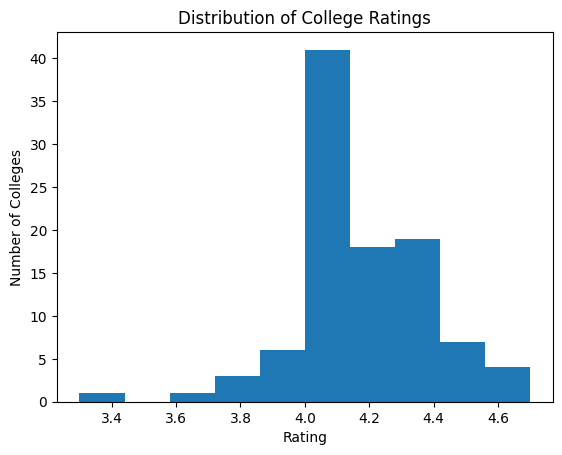

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["Rating"], bins=10)
plt.xlabel("Rating")
plt.ylabel("Number of Colleges")
plt.title("Distribution of College Ratings")
plt.show()

This histogram shows Distribution of College Ratings where 4.0 is th highest rating for 40 colleges.Very few colleges have extremely low or extremely high ratings.

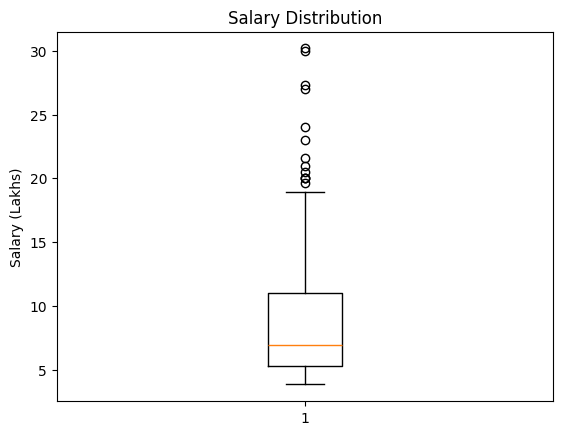

In [ ]:
plt.boxplot(df["Salary"].dropna())
plt.ylabel("Salary (Lakhs)")
plt.title("Salary Distribution")
plt.show()

Points outside the normal range represent possible outliers.
Some colleges have considerably higher salary values than the majority.

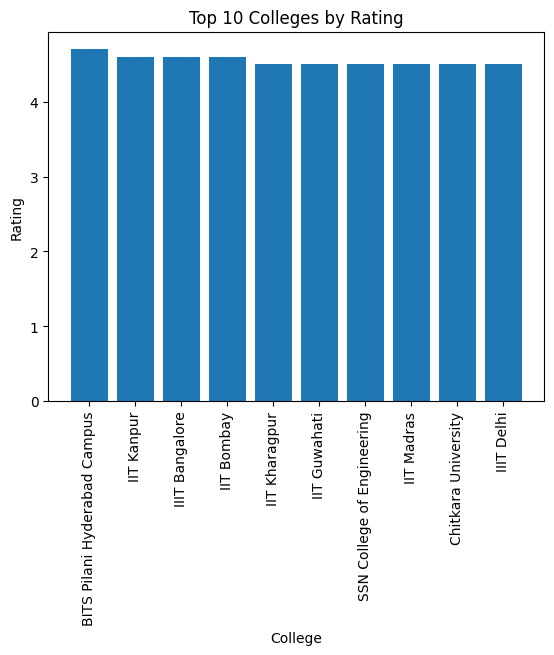

In [ ]:
top_10 = df.sort_values("Rating", ascending=False).head(10)

plt.bar(top_10["College"], top_10["Rating"])
plt.xlabel("College")
plt.ylabel("Rating")
plt.title("Top 10 Colleges by Rating")
plt.xticks(rotation=90)
plt.show()

The chart compares the ratings of the top 10 colleges.
Colleges near the top have higher ratings than the other colleges in the dataset.
The difference between some colleges may be small because their ratings are close.

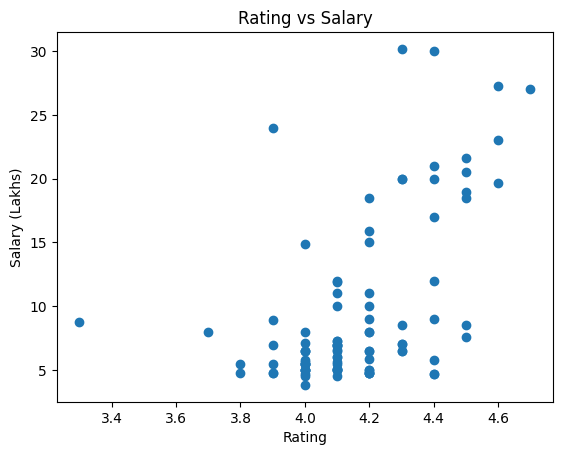

In [ ]:
plt.scatter(df["Rating"], df["Salary"])
plt.xlabel("Rating")
plt.ylabel("Salary (Lakhs)")
plt.title("Rating vs Salary")
plt.show()

If the points generally move upward from left to right, higher-rated colleges tend to have higher salaries.
However, the points are not necessarily perfectly aligned, so rating alone does not determine salary.

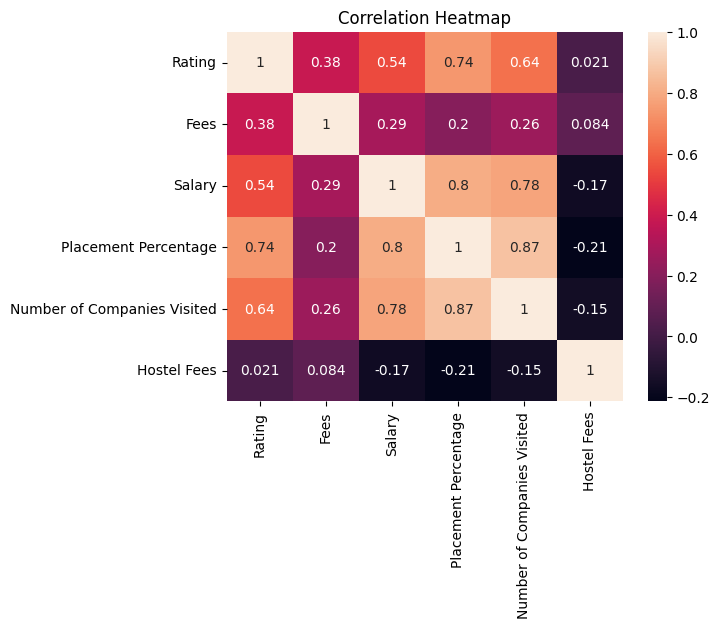

In [ ]:
import seaborn as sns

columns = [
    "Rating",
    "Fees",
    "Salary",
    "Placement Percentage",
    "Number of Companies Visited",
    "Hostel Fees"
]

correlation = df[columns].corr()

sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows the correlation between the numerical columns.
Values close to +1 indicate a strong positive relationship.
Values close to -1 indicate a strong negative relationship.
Values close to 0 indicate a weak or no linear relationship.
The diagonal values are 1 because each variable has a perfect correlation with itself.

In [59]:
import pandas as pd

faq = pd.read_csv("data.csv")

X = faq["Question"]
y = faq["Intent"]

In [56]:
results = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

print(results)

    Actual Salary  Predicted Salary
0            5.90          6.963979
1            7.13         10.921716
2            7.00          4.623390
3            6.50          6.513021
4           18.96         22.152484
5           15.00         12.894079
6           27.30         18.814237
7           14.85         14.298526
8           20.00         15.360301
9           10.00         10.504985
10           5.80          9.759862
11           5.10          4.865982
12           7.00          7.089611
13           4.80          5.776571
14          30.18         17.956491
15          17.00         18.737111
16           9.00         16.270889
17          12.00         13.349374
18          30.00         12.971206


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [64]:
y_pred = model.predict(X_test)

print(y_pred)

['Fees' 'Fees' 'Fees' 'Salary' 'Rating' 'State' 'Safety Details'
 'Number of Companies Visited' 'Placement Percentage' 'Fees'
 'Quality of Food' 'Fees']


In [67]:
def ask_chatbot(question):

    question_vector = vectorizer.transform([question])

    intent = model.predict(question_vector)[0]

    print("Question:", question)
    print("Predicted Intent:", intent)

In [68]:
ask_chatbot("What is the fee of IIT Madras?")

Question: What is the fee of IIT Madras?
Predicted Intent: Fees


In [82]:
def ask_chatbot(question):

    question_vector = vectorizer.transform([question])

    intent = model.predict(question_vector)[0]

    college_name = None

    # Iterate through the College column of the df DataFrame
    for name in df["College"]:
        if str(name).lower() in question.lower():
            college_name = name
            break

    if college_name is None:
        print("College not found")
        return

    # Use the df DataFrame to retrieve the college information
    if intent == "Fees":
        answer = df.loc[
            df["College"] == college_name, "Fees"
        ].iloc[0]

    elif intent == "Rating":
        answer = df.loc[
            df["College"] == college_name, "Rating"
        ].iloc[0]

    elif intent == "Salary":
        answer = df.loc[
            df["College"] == college_name, "Salary"
        ].iloc[0]

    elif intent == "Placement Percentage":
        answer = df.loc[
            df["College"] == college_name,
            "Placement Percentage"
        ].iloc[0]

    elif intent == "Number of Companies Visited":
        answer = df.loc[
            df["College"] == college_name,
            "Number of Companies Visited"
        ].iloc[0]

    elif intent == "Quality of Food":
        answer = df.loc[
           df["College"] == college_name,
            "Quality of Food"
        ].iloc[0]

    elif intent == "Hostel Fees":
        answer = df.loc[
            df["College"] == college_name,
            "Hostel Fees"
        ].iloc[0]

    elif intent == "Safety Details":
        answer = df.loc[
            df["College"] == college_name,
            "Safety Details"
        ].iloc[0]

    elif intent == "Entrance Exam":
        answer = df.loc[
            df["College"] == college_name,
            "Entrance Exam"
        ].iloc[0]

    elif intent == "State":
        answer = df.loc[
            df["College"] == college_name,
            "State"
        ].iloc[0]

    else:
        answer = "Information not available."

    print("Answer:", answer)

In [80]:
print(type(faq))
print(faq)

<class 'pandas.core.frame.DataFrame'>
                                             Question     College  \
0                      What is the fee of IIT Madras?  IIT Madras   
1                      How much does IIT Madras cost?  IIT Madras   
2                   What are the fees for IIT Madras?  IIT Madras   
3                       Tell me the fee of IIT Madras  IIT Madras   
4          How much is the college fee at IIT Madras?  IIT Madras   
5              What is the tuition fee of IIT Madras?  IIT Madras   
6                   What is the rating of IIT Madras?  IIT Madras   
7                            How is IIT Madras rated?  IIT Madras   
8                   What rating does IIT Madras have?  IIT Madras   
9                             How good is IIT Madras?  IIT Madras   
10          What is the salary offered at IIT Madras?  IIT Madras   
11          What is the average salary at IIT Madras?  IIT Madras   
12  How much salary can students get from IIT Madras?  IIT Madras

In [81]:
print(df.columns)
print(faq.columns)

Index(['Rank', 'College', 'Rating', 'Fees', 'Salary', 'Entrance Exam', 'State',
       'Placement Percentage', 'Number of Companies Visited',
       'Quality of Food', 'Hostel Fees', 'Safety Details'],
      dtype='object')
Index(['Question', 'College', 'Intent'], dtype='object')


In [84]:
ask_chatbot("How is IIT Delhi rated?")

Answer: 4.5


In [85]:
ask_chatbot("What is the fee of IIT Madras?")

Answer: 8.0
